In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('https://storage.yandexcloud.net/uol/programming/adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# '?' -> NaN
df.replace('?', np.nan, inplace=True)
# trim ' ' empty rows
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

print("\nMissing values before preprocessing:")
print(df.isnull().sum())


Missing values before preprocessing:
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [ ]:

print("filling empty values")
df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)
df['occupation'].fillna(df['occupation'].mode()[0], inplace=True)
df['native-country'].fillna(df['native-country'].mode()[0], inplace=True)


# print(df.isin(['?']).sum())
# print(f"\ntotal:  {df.isin(['?']).sum().sum()}")
# df.to_csv('temp.csv', index=False)

# Now encode ALL categorical variables
from sklearn.preprocessing import LabelEncoder

# Initialize label encoder
label_encoder = LabelEncoder()

print("\nOriginal workclass values:", df['workclass'].unique())
df['workclass_encoded'] = label_encoder.fit_transform(df['workclass'])
print("Encoded workclass values:", df['workclass_encoded'].unique())

print("\nOriginal education values:", df['education'].unique())
df['education_encoded'] = label_encoder.fit_transform(df['education'])
print("Encoded education values:", df['education_encoded'].unique())

print("\nOriginal marital-status values:", df['marital-status'].unique())
df['marital_status_encoded'] = label_encoder.fit_transform(df['marital-status'])
print("Encoded marital_status values:", df['marital_status_encoded'].unique())

print("\nOriginal occupation values:", df['occupation'].unique())
df['occupation_encoded'] = label_encoder.fit_transform(df['occupation'])
print("Encoded occupation values:", df['occupation_encoded'].unique())

print("\nOriginal relationship values:", df['relationship'].unique())
df['relationship_encoded'] = label_encoder.fit_transform(df['relationship'])
print("Encoded relationship values:", df['relationship_encoded'].unique())

print("\nOriginal race values:", df['race'].unique())
df['race_encoded'] = label_encoder.fit_transform(df['race'])
print("Encoded race values:", df['race_encoded'].unique())

print("\nOriginal gender values:", df['gender'].unique())
df['gender_encoded'] = label_encoder.fit_transform(df['gender'])
print("Encoded gender values:", df['gender_encoded'].unique())

print("\nOriginal native-country values:", df['native-country'].unique())
df['native-country_encoded'] = label_encoder.fit_transform(df['native-country'])
print("Encoded native-country values:", df['native-country_encoded'].unique())

print("\nOriginal income values:", df['income'].unique())
df['income_encoded'] = label_encoder.fit_transform(df['income'])
print("Encoded income values:", df['income_encoded'].unique())

filling empty values

Original workclass values: ['Private' 'Local-gov' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Encoded workclass values: [3 1 5 0 6 4 7 2]

Original education values: ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']
Encoded education values: [ 1 11  7 15  0 14  5  9 12 10  4  8  6  2  3 13]

Original marital-status values: ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']
Encoded marital_status values: [4 2 6 0 5 3 1]

Original occupation values: ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' 'Prof-specialty'
 'Other-service' 'Craft-repair' 'Adm-clerical' 'Exec-managerial'
 'Tech-support' 'Sales' 'Priv-house-serv' 'Transport-moving'
 'Handlers-cleaners' 'Armed-Forces']
Encoded occupation values: [ 6  4 10  9  7  2  0  3 12 

/tmp/ipython-input-444996951.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)
/tmp/ipython-input-444996951.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

Encoded gender values: [1 0]

Original native-country values: ['United-States' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany' 'Philippines' 'Thailand' 'Haiti' 'El-Salvador'
 'Puerto-Rico' 'Vietnam' 'South' 'Columbia' 'Japan' 'India' 'Cambodia'
 'Poland' 'Laos' 'England' 'Cuba' 'Taiwan' 'Italy' 'Canada' 'Portugal'
 'China' 'Nicaragua' 'Honduras' 'Iran' 'Scotland' 'Jamaica' 'Ecuador'
 'Yugoslavia' 'Hungary' 'Hong' 'Greece' 'Trinadad&Tobago'
 'Outlying-US(Guam-USVI-etc)' 'France' 'Holand-Netherlands']
Encoded native-country values: [38 28 12 25  5 20 10 29 36 13  7 32 39 34  3 23 18  0 30 24  8  4 35 21
  1 31  2 26 15 19 33 22  6 40 17 16 11 37 27  9 14]

Original income values: ['<=50K' '>50K']
Encoded income values: [0 1]


In [ ]:
df_processed = pd.DataFrame({
    'age': df['age'],
    'workclass': df['workclass_encoded'],
    'education': df['education_encoded'],
    'marital-status': df['marital_status_encoded'],
    'occupation': df['occupation_encoded'],
    'relationship': df['relationship_encoded'],
    'race': df['race_encoded'],
    'hours-per-week': df['hours-per-week'],
    'native-country': df['native-country_encoded'],
    'income': df['income_encoded'],
    'fnlwgt': df['fnlwgt']
})

df_processed = df_processed.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal processed dataset:")
print(df_processed.head())
print("\nData types after preprocessing:")
print(df_processed.dtypes)
print("\nMissing values after preprocessing:")
print(df_processed.isnull().sum())


Final processed dataset:
   age  workclass  education  marital-status  occupation  relationship  race  \
0   56          3         11               0           7             4     4   
1   25          3         11               2          13             3     3   
2   43          3          9               0           9             1     4   
3   32          3         11               2          13             0     4   
4   39          3          9               2          11             5     4   

   hours-per-week  native-country  income  fnlwgt  
0              40              38       0   33115  
1              40              38       0  112847  
2              40              38       1  170525  
3              40              38       0  186788  
4              30              38       0  277886  

Data types after preprocessing:
age               int64
workclass         int64
education         int64
marital-status    int64
occupation        int64
relationship      int64
race

In [ ]:
# Use the label-encoded dataset
X = df_processed.drop('income', axis=1)
y = df_processed['income']

print("Features (X) shape:", X.shape)
print("Features (X):")
print(X.head())
print("\nTarget variable (y):")
print(y.head())

# Verify all columns are numeric
print("\nFeature data types:")
print(X.dtypes)

# Split the data
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 2) Split remaining data into train (60%) and validation (20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp,
    test_size=0.17647058823, # Z*0.85 =
    random_state=42,
    stratify=y_temp
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Validation set size: {X_valid.shape}")
print(f"Testing set size: {X_test.shape}")

Features (X) shape: (48842, 10)
Features (X):
   age  workclass  education  marital-status  occupation  relationship  race  \
0   56          3         11               0           7             4     4   
1   25          3         11               2          13             3     3   
2   43          3          9               0           9             1     4   
3   32          3         11               2          13             0     4   
4   39          3          9               2          11             5     4   

   hours-per-week  native-country  fnlwgt  
0              40              38   33115  
1              40              38  112847  
2              40              38  170525  
3              40              38  186788  
4              30              38  277886  

Target variable (y):
0    0
1    0
2    1
3    0
4    0
Name: income, dtype: int64

Feature data types:
age               int64
workclass         int64
education         int64
marital-status    int64
occupati

In [ ]:
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Validation accuracy
dt_val_accuracy = dt_model.score(X_valid, y_valid)
print("Decision Tree Validation Accuracy:", dt_val_accuracy)

Decision Tree Validation Accuracy: 0.8180701514944725


In [ ]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Validation accuracy
rf_val_accuracy = rf_model.score(X_valid, y_valid)
print("Random Forest Validation Accuracy:", rf_val_accuracy)

Random Forest Validation Accuracy: 0.8298075610754743


In [ ]:
"""
# Make a set of logistic Regression Models
param_grid = {
    'C': [100, 1000],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}


grid = GridSearchCV(LogisticRegression(max_iter=10000, random_state=15),
                    param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
"""

'\n# Make a set of logistic Regression Models\nparam_grid = {\n    \'C\': [100, 1000],\n    \'penalty\': [\'l1\', \'l2\'],\n    \'solver\': [\'liblinear\', \'lbfgs\'],\n    \'class_weight\': [None, \'balanced\']\n}\n\n\ngrid = GridSearchCV(LogisticRegression(max_iter=10000, random_state=15),\n                    param_grid, cv=3, scoring=\'accuracy\')\ngrid.fit(X_train, y_train)\nprint("Best params:", grid.best_params_)\n'

In [ ]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(
    C=1000,
    penalty='l2',
    random_state=15,
    max_iter = 10000,
)

# Train the model
lr_model.fit(X_train, y_train)

# Validation accuracy
lr_val_accuracy = lr_model.score(X_valid, y_valid)
print("Logistic Regression Validation Accuracy:", lr_val_accuracy)

Logistic Regression Validation Accuracy: 0.7591101405759519


In [ ]:

print("\nValidation Accuracy Summary")
print("----------------------------")
print(f"Decision Tree:      {dt_val_accuracy:.4f}")
print(f"Random Forest:      {rf_val_accuracy:.4f}")
print(f"Logistic Regression:{lr_val_accuracy:.4f}")


Validation Accuracy Summary
----------------------------
Decision Tree:      0.8181
Random Forest:      0.8298
Logistic Regression:0.7591


In [ ]:
# Use the validation results only to choose the best model
# Use the test set results in Part 3 as your final performance
# Based on validation accuracy, the Random Forest classifier performed best and was selected for final evaluation on the test set
# Model	Validation Accuracy :
# Decision Tree	0.83
# Random Forest	0.86
# Logistic Regression	0.81


In [ ]:

# SUMMARY OF VALIDATION PERFORMANCE

print("\nValidation Accuracy Summary")
# Prints a blank line followed by a title to clearly indicate
# the start of the validation accuracy results section.

print("----------------------------")
# Prints a horizontal separator to improve readability and
# visually separate the title from the results.

print(f"Decision Tree:      {dt_val_accuracy:.4f}")
# Displays the validation accuracy of the Decision Tree model.
# The value is formatted to four decimal places for consistency
# and professional presentation.

print(f"Random Forest:      {rf_val_accuracy:.4f}")
# Displays the validation accuracy of the Random Forest model.
# This allows direct comparison with the Decision Tree and
# shows whether ensemble learning improves performance.

print(f"Logistic Regression:{lr_val_accuracy:.4f}")
# Displays the validation accuracy of the Logistic Regression
# model, which serves as a baseline for comparison against
# more complex tree-based models.



Validation Accuracy Summary
----------------------------
Decision Tree:      0.8181
Random Forest:      0.8298
Logistic Regression:0.7591


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Needed for ROC-AUC

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n {model_name} Performance:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    }



In [ ]:

e1 = evaluate_model(dt_model, X_test, y_test, "Decision Tree")
e2 = evaluate_model(rf_model, X_test, y_test, "Random Forest")
e3 = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")



 Decision Tree Performance:
Accuracy : 0.8249
Precision: 0.6487
Recall   : 0.5847
F1-score : 0.6151
ROC-AUC  : 0.8510

 Random Forest Performance:
Accuracy : 0.8361
Precision: 0.6857
Recall   : 0.5813
F1-score : 0.6292
ROC-AUC  : 0.8846

 Logistic Regression Performance:
Accuracy : 0.7642
Precision: 0.5214
Recall   : 0.1734
F1-score : 0.2603
ROC-AUC  : 0.7616


In [ ]:
results_df = pd.DataFrame([e1, e2, e3])
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.824894,0.648734,0.584712,0.615062,0.851017
1,Random Forest,0.836086,0.685734,0.581289,0.629207,0.884578
2,Logistic Regression,0.764160,0.521441,0.173417,0.260274,0.761604


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt


In [ ]:
def plot_confusion_matrix(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix – {model_name}")
    plt.show()




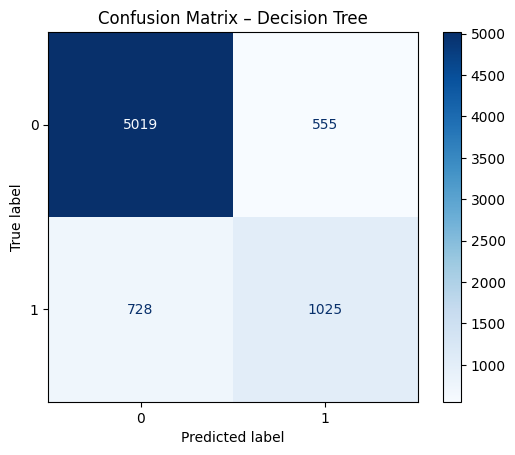

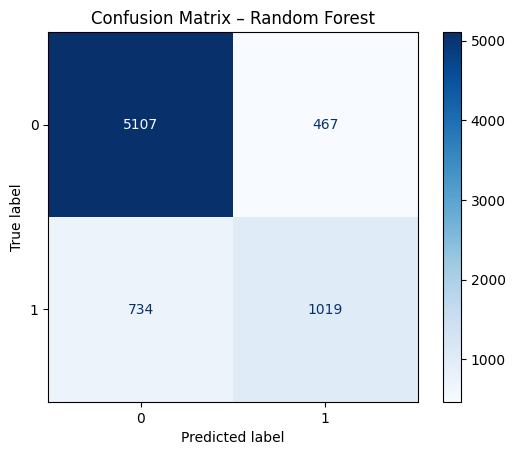

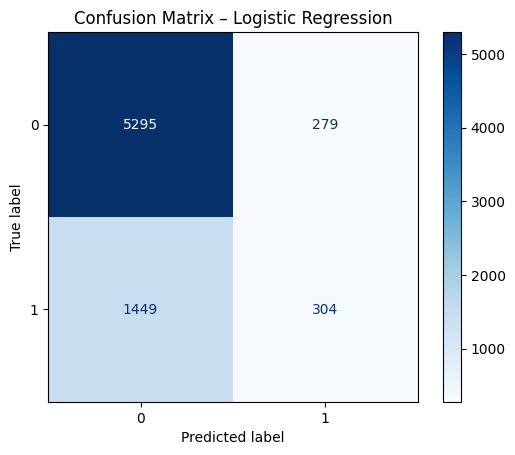

In [ ]:
plot_confusion_matrix(dt_model, X_test, y_test, "Decision Tree")
plot_confusion_matrix(rf_model, X_test, y_test, "Random Forest")
plot_confusion_matrix(lr_model, X_test, y_test, "Logistic Regression")


In [ ]:
def plot_roc_curve(model, X_test, y_test, model_name):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=model_name)


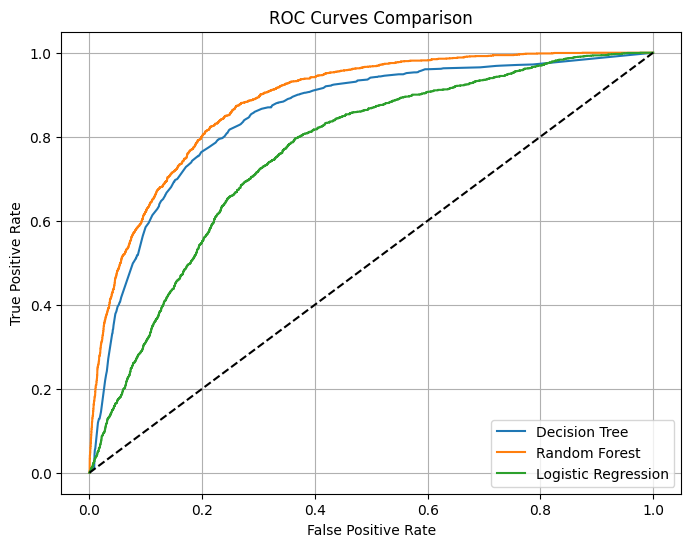

In [ ]:
plt.figure(figsize=(8, 6))

plot_roc_curve(dt_model, X_test, y_test, "Decision Tree")
plot_roc_curve(rf_model, X_test, y_test, "Random Forest")
plot_roc_curve(lr_model, X_test, y_test, "Logistic Regression")

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
results_df = pd.DataFrame([e1, e2, e3])
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.824894,0.648734,0.584712,0.615062,0.851017
1,Random Forest,0.836086,0.685734,0.581289,0.629207,0.884578
2,Logistic Regression,0.764160,0.521441,0.173417,0.260274,0.761604


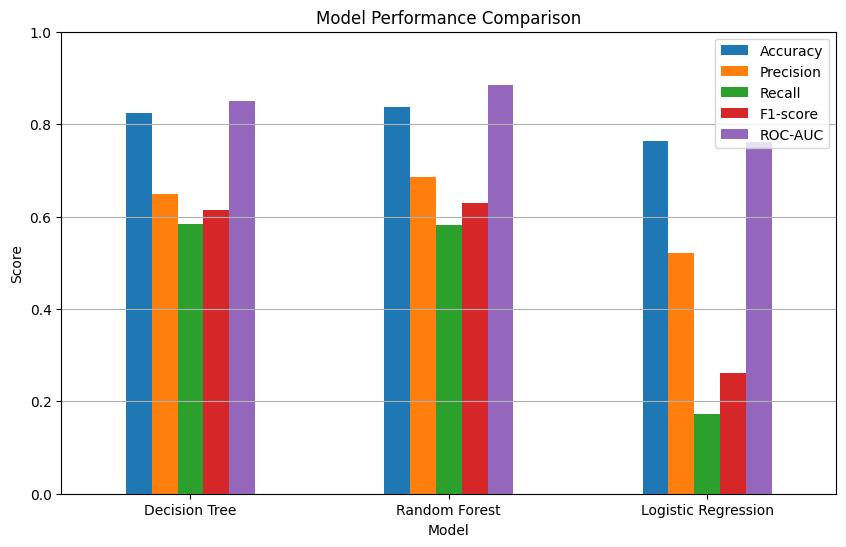

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
cv_dt = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
cv_lr = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')


In [ ]:
print("Decision Tree CV Accuracy: {:.4f} ± {:.4f}".format(cv_dt.mean(), cv_dt.std()))
print("Random Forest CV Accuracy: {:.4f} ± {:.4f}".format(cv_rf.mean(), cv_rf.std()))
print("Logistic Regression CV Accuracy: {:.4f} ± {:.4f}".format(cv_lr.mean(), cv_lr.std()))


Decision Tree CV Accuracy: 0.8253 ± 0.0017
Random Forest CV Accuracy: 0.8374 ± 0.0032
Logistic Regression CV Accuracy: 0.7625 ± 0.0015


In [ ]:
from sklearn.tree import plot_tree


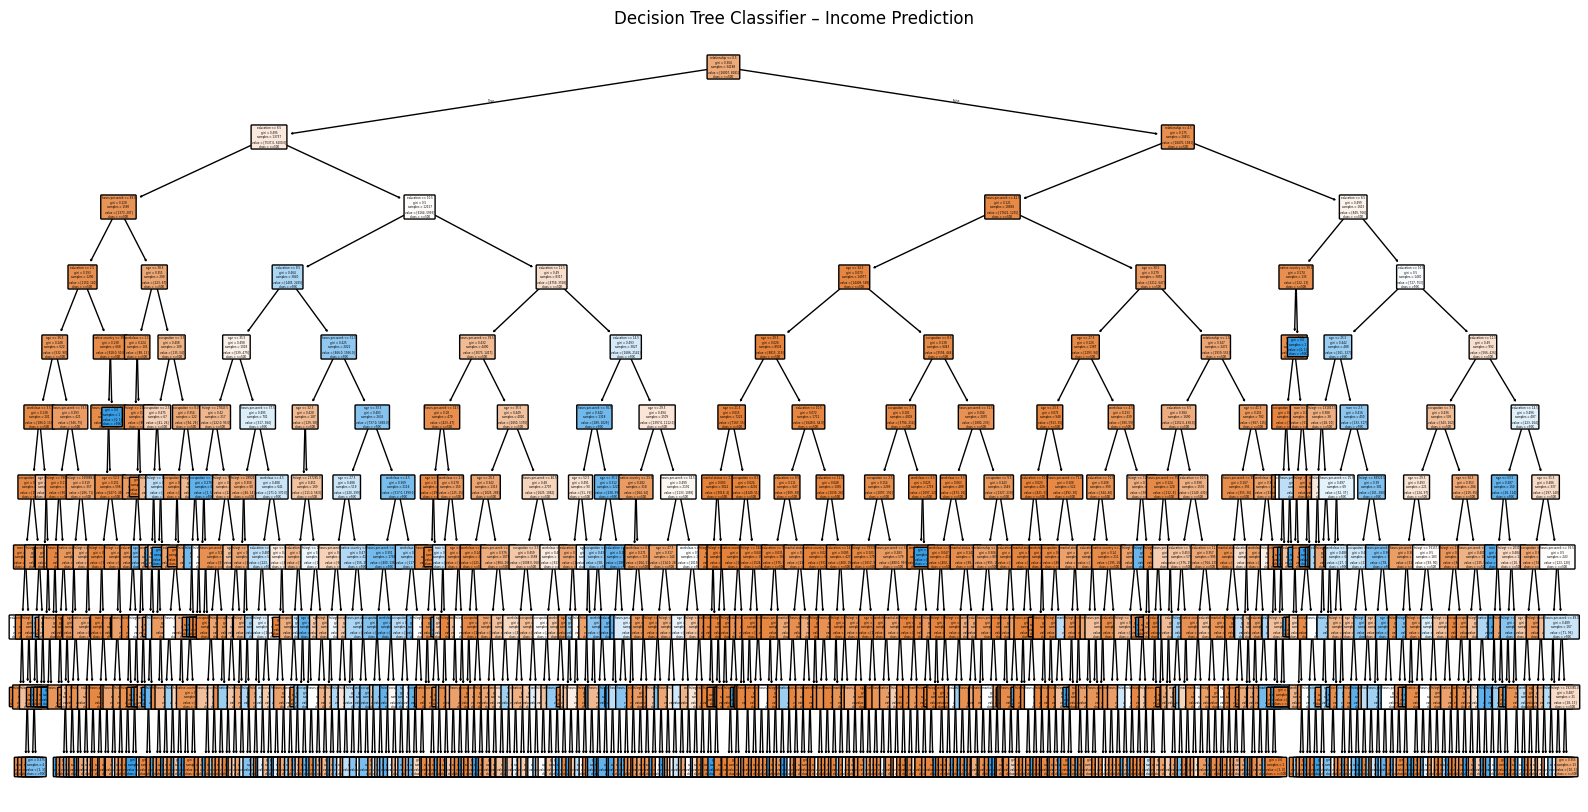

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=2
)

plt.title("Decision Tree Classifier – Income Prediction")
plt.show()


In [ ]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

dt_importance


,Feature,Importance
5,relationship,0.467423
2,education,0.254887
0,age,0.084651
7,hours-per-week,0.075406
9,fnlwgt,0.047368
4,occupation,0.028498
1,workclass,0.024772
8,native-country,0.006317
6,race,0.005405
3,marital-status,0.005274


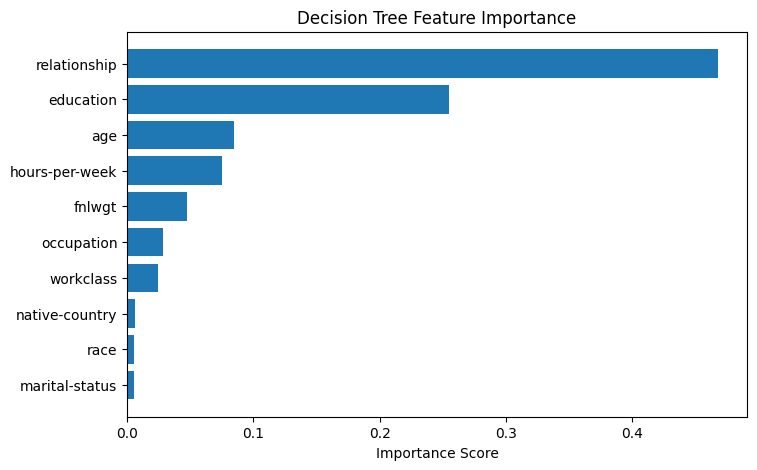

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(dt_importance["Feature"], dt_importance["Importance"])
plt.xlabel("Importance Score")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()
